In [1]:
import argparse
import pickle
import gzip
import json
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import copy
from hist import Hist 
import ewkcoffea.modules.plotting_tools as plt_tools


In [5]:
pkl_file_path = "output/test_jan13/hists_all_events.pkl.gz"
histo_dict = pickle.load(gzip.open(pkl_file_path))

In [6]:
histo_dict

{'met_pt': Hist(
   StrCategory(['2016postVFP_VBSWWH_OS_C2V_1p0_C3_10p0_13TeV_4f_LO', '2017_VBSWWH_OS_C2V_1p0_C3_10p0_13TeV_4f_LO', '2018_VBSWWH_OS_C2V_1p0_C3_10p0_13TeV_4f_LO', '2016preVFP_VBSWWH_OS_C2V_1p0_C3_10p0_13TeV_4f_LO'], growth=True, name='process'),
   StrCategory(['all_events_all_events'], growth=True, name='category'),
   StrCategory(['nominal', 'count'], growth=True, name='systematic'),
   Regular(100, 0, 1000, name='met_pt', label='MET $p_T$ [GeV]'),
   storage=Weight()) # Sum: WeightedSum(value=196054, variance=195971) (WeightedSum(value=196057, variance=195974) with flow),
 'met_phi': Hist(
   StrCategory(['2016postVFP_VBSWWH_OS_C2V_1p0_C3_10p0_13TeV_4f_LO', '2017_VBSWWH_OS_C2V_1p0_C3_10p0_13TeV_4f_LO', '2018_VBSWWH_OS_C2V_1p0_C3_10p0_13TeV_4f_LO', '2016preVFP_VBSWWH_OS_C2V_1p0_C3_10p0_13TeV_4f_LO'], growth=True, name='process'),
   StrCategory(['all_events_all_events'], growth=True, name='category'),
   StrCategory(['nominal', 'count'], growth=True, name='systematic')

In [3]:
histo_dict

{'nGoodAK4': Hist(
   StrCategory(['2017_VBSZZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2018_VBSZZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2018_QCD_HT700to1000', '2017_QCD_HT700to1000', '2018_QCD_HT500to700', '2018_QCD_HT1500to2000', '2016postVFP_VBSWZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2017_VBSWZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2018_VBSWZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2016postVFP_VBSWWH_SS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2017_VBSWWH_SS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2016preVFP_VBSWWH_OS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2016postVFP_VBSWWH_OS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2016preVFP_QCD_HT700to1000', '2016preVFP_VBSZZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2016postVFP_VBSZZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2018_VBSWWH_SS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2016preVFP_VBSWZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2017_VBSWWH_OS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2018_VBSWWH_OS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2017_QCD_HT1500to2000', '2017_QCD_HT500to700', '2017_TTToHadronic', '2016preVFP_TTToHadronic', '2018_TTToHadronic', '2016postVFP_TTToHadronic

In [22]:
variables = [k for k in histo_dict if isinstance(histo_dict[k], Hist)]
print(variables)    

systematic = 'nominal'
categories = None
first_h = histo_dict[variables[0]]
if categories is None:
        categories = list(first_h.axes["category"])


groups = None
density = False
all_processes = list(first_h.axes["process"])
print(f"all_processes = {all_processes}")
if groups is None:
    groups = {p: [p] for p in all_processes}        

['nGoodAK4']
all_processes = ['2017_VBSZZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2018_VBSZZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2016preVFP_QCD_HT700to1000', '2017_QCD_HT700to1000', '2018_QCD_HT700to1000', '2016postVFP_VBSWWH_SS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2017_VBSWWH_SS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2016postVFP_VBSWZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2017_VBSWZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2018_VBSWZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2016postVFP_VBSWWH_OS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2017_VBSWWH_OS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2018_VBSWWH_OS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2017_QCD_HT1500to2000', '2017_QCD_HT500to700', '2018_QCD_HT500to700', '2017_QCD_HT1000to1500', '2016postVFP_QCD_HT1500to2000', '2016postVFP_QCD_HT700to1000', '2018_QCD_HT1000to1500', '2016postVFP_QCD_HT500to700', '2018_QCD_HT1500to2000', '2016preVFP_QCD_HT1000to1500', '2017_QCD_HT2000toInf', '2018_QCD_HT200to300', '2016preVFP_QCD_HT500to700', '2016preVFP_QCD_HT1500to2000', '2018_QCD_HT300to500', '2016preVFP_QCD_HT300to500', '2016po

Retrieving histogram nGoodAK4
['2017_VBSZZH_C2V_1p5_C3_1p0_13TeV_4f_LO']
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25.]
['2018_VBSZZH_C2V_1p5_C3_1p0_13TeV_4f_LO']
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25.]
['2016preVFP_QCD_HT700to1000']
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25.]
['2017_QCD_HT700to1000']
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25.]
['2018_QCD_HT700to1000']
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25.]
['2016postVFP_VBSWWH_SS_C2V_1p5_C3_1p0_13TeV_4f_LO']
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25.]
['2017_VBSWWH_SS_C2V_1p5_C3_1p0_13TeV_4f_LO']
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 1

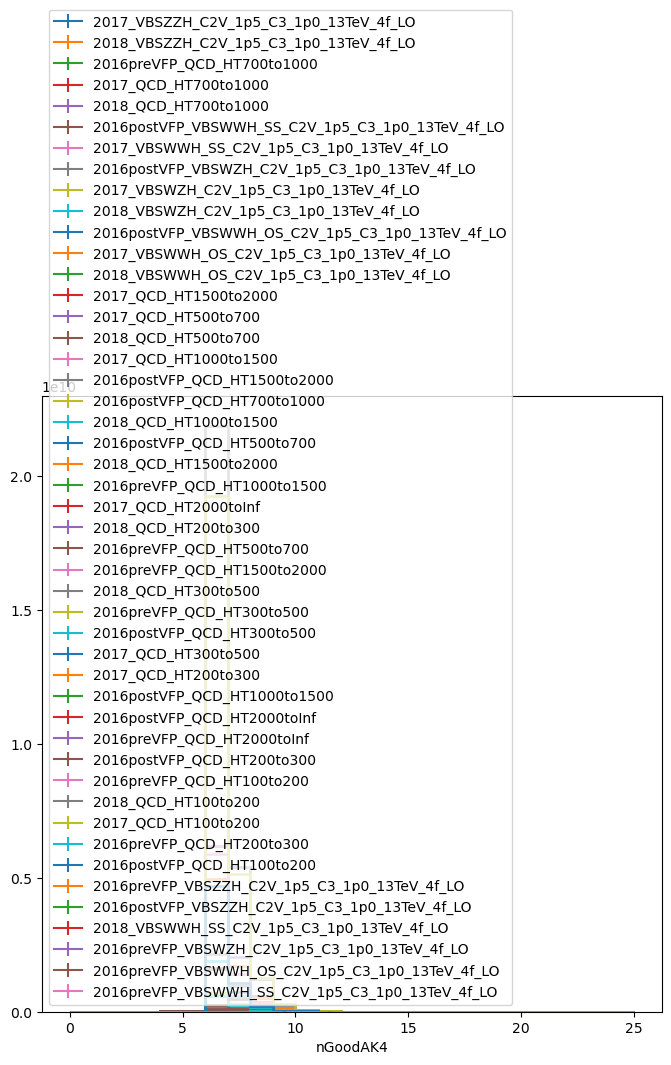

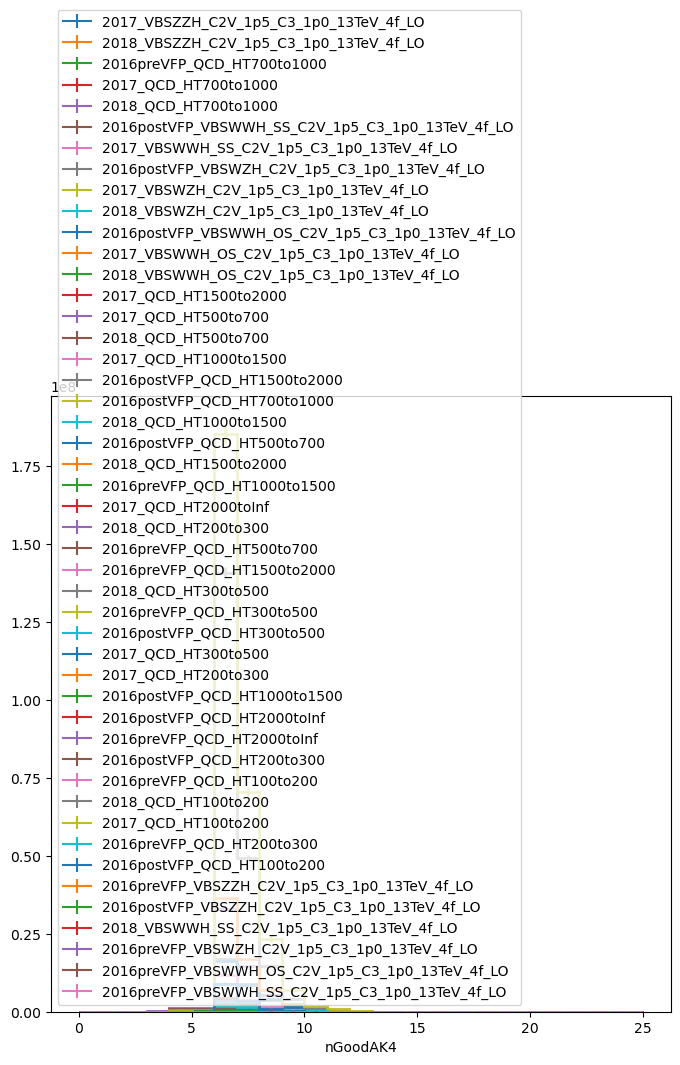

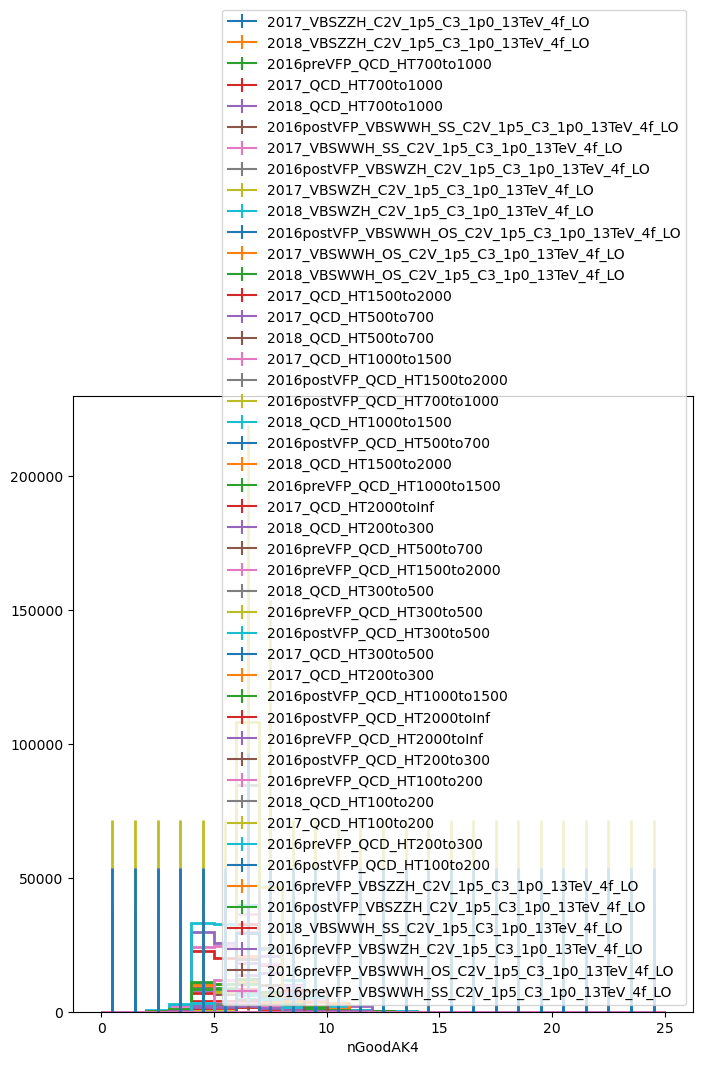

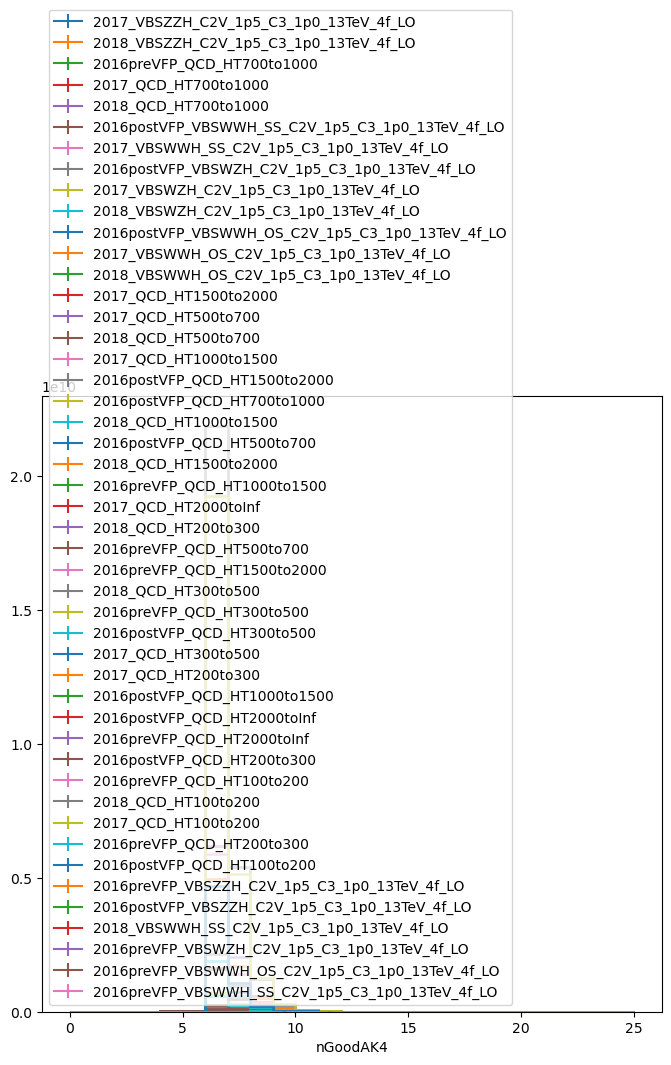

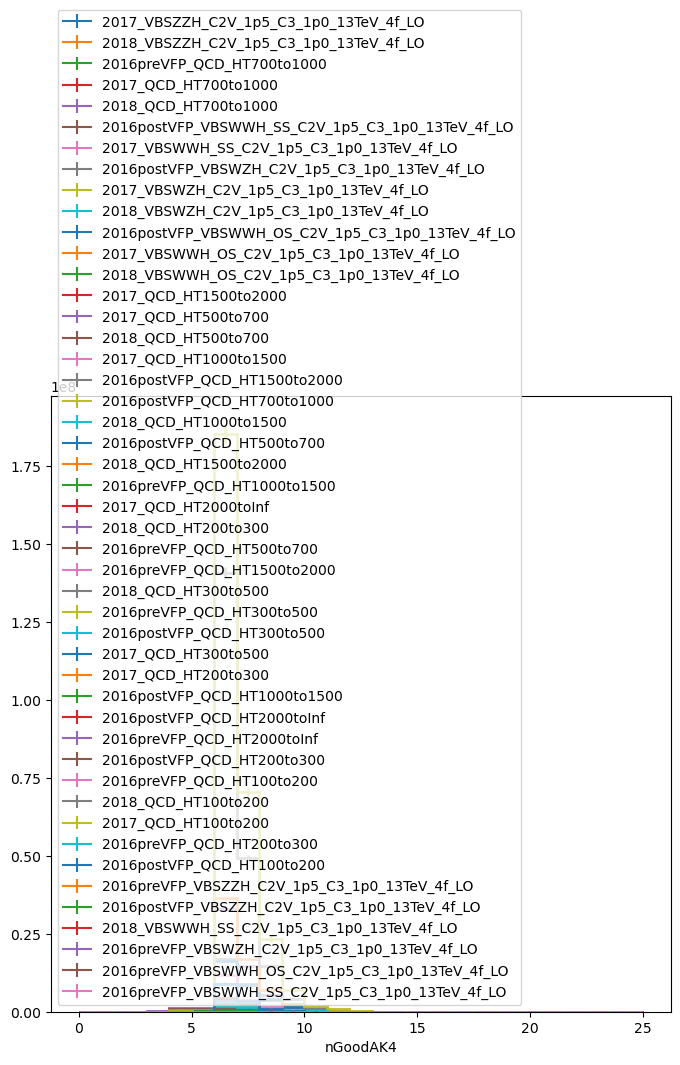

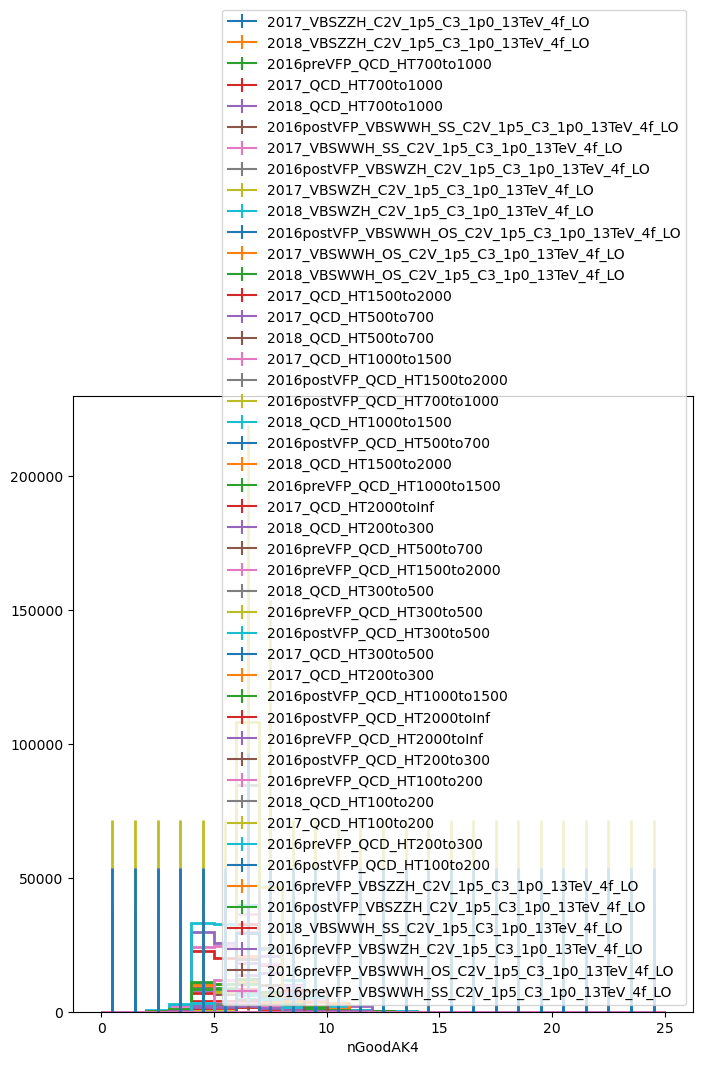

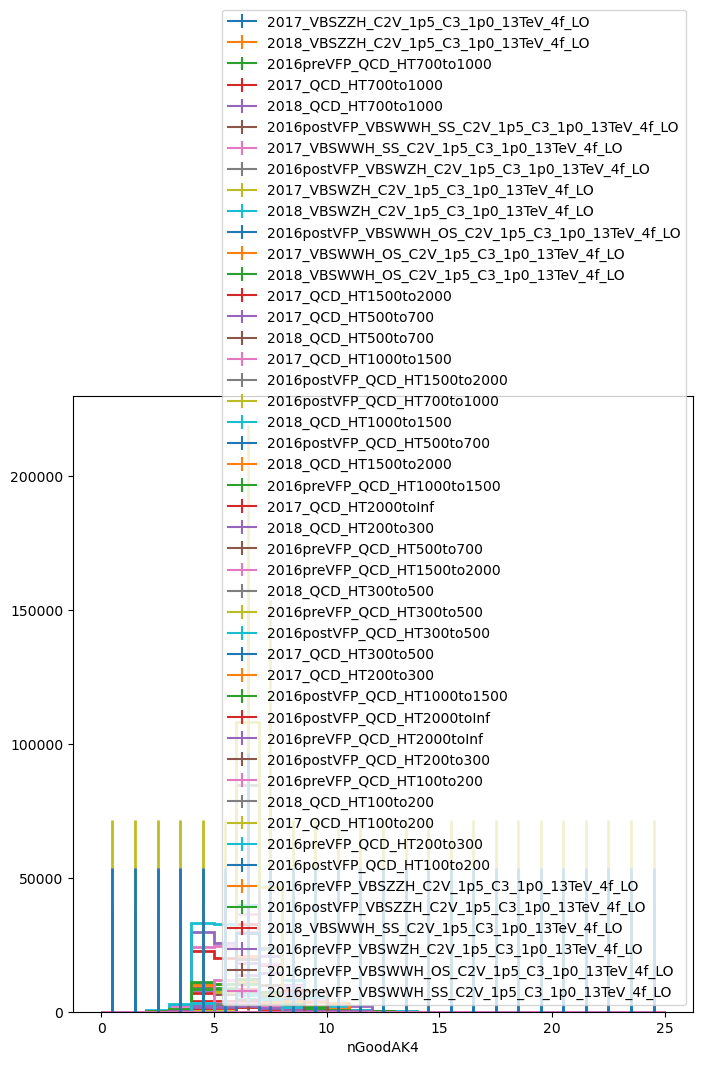

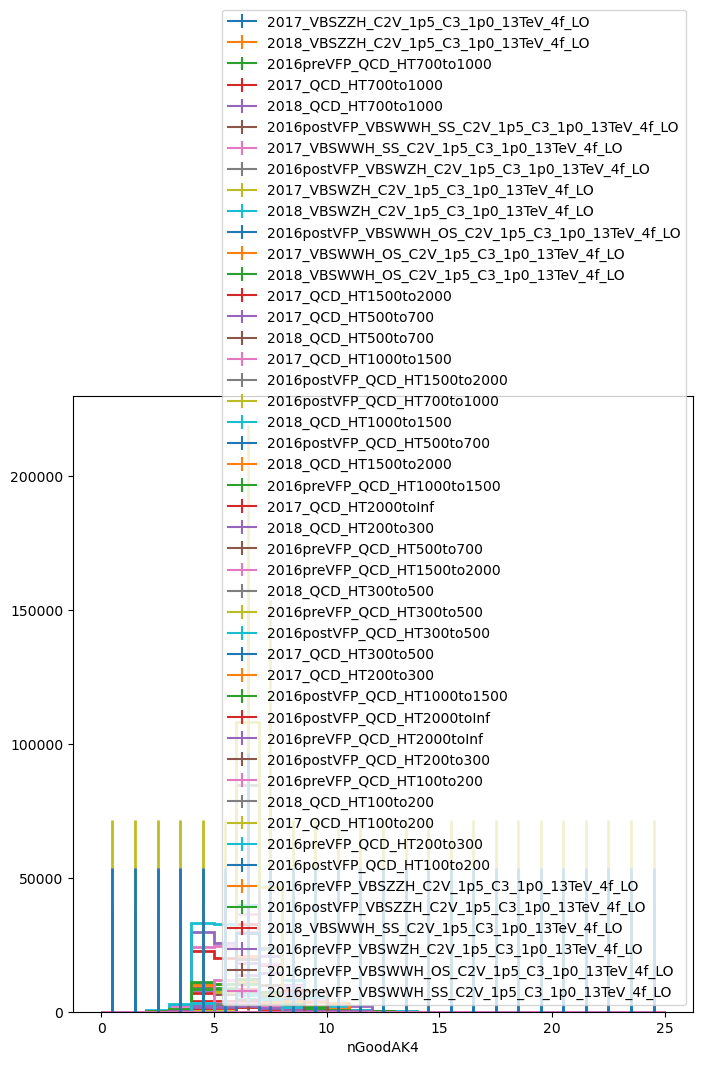

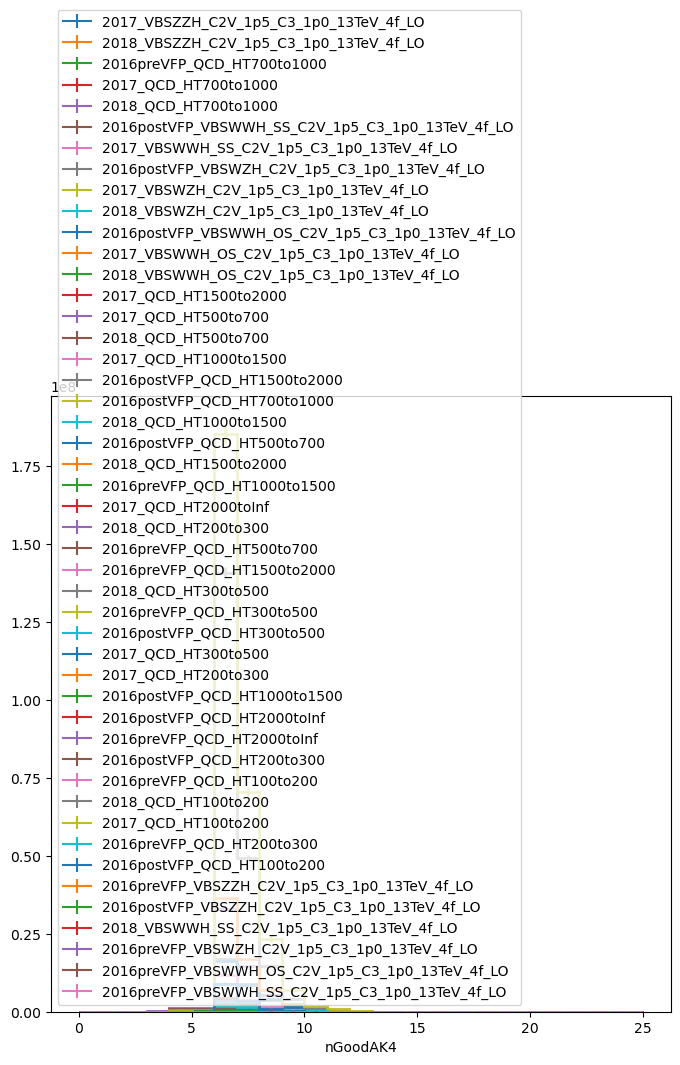

In [24]:
for cat in categories:
    for var in variables:
            if var not in histo_dict:
                print(f"Skipping missing histogram: {var}")
                continue
            else: 
                print(f"Retrieving histogram {var}")
            
            h = histo_dict[var]
            fig, ax = plt.subplots(figsize=(8, 8)) 
            for group_name, procs in groups.items():
                # Filter to existing processes
                existing_procs = [p for p in procs if p in all_processes]
                print(existing_procs)      
                h_group = sum(h[{"process": p, "category": cat, "systematic": systematic}] for p in existing_procs)   

                # fix if year is in axes, but year already in the name of the process
                # if existing_procs:                  
                #     year = existing_procs[0].split('_')[0]
                #     print(year)
                #     h_group = h_group[{"year": year}]       

                h_group.plot(ax=ax, label=group_name, histtype="step", linewidth=2, density=density)
                h_bins = h_group.axes[0].edges 
                plt.legend()
                print(h_bins)

                #break
            #break
    #break

In [17]:
h_group.values()


array([0.00000000e+00, 0.00000000e+00, 1.14419100e-02, 9.87962933e-02,
       7.07341496e-01, 1.26006222e+00, 2.50964941e+00, 2.32137015e+00,
       1.66307934e+00, 8.39189845e-01, 2.97497339e-01, 1.01104584e-01,
       2.77766745e-02, 7.29049561e-03, 1.93564421e-03, 7.40746608e-04,
       1.57555027e-04, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00])

ValueError: The axis name year could not be found

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7ff36d7d5df0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

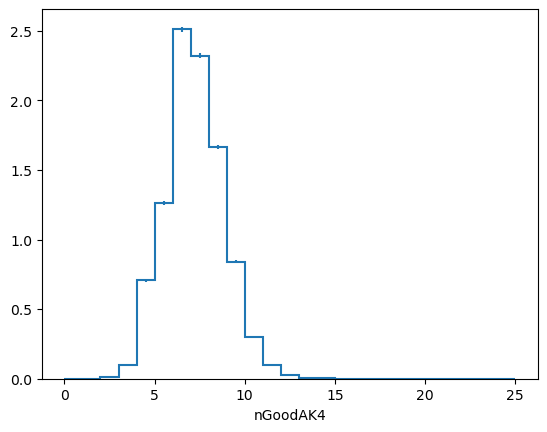

In [19]:
h_group.plot()

In [ ]:

    h = histo_dict["nGoodAK8"]
    
    processes = list(h.axes["process"])
    print(processes)
    categories = list(h.axes["category"])
    print(categories)
    
    yields = {}
    for proc in processes:
        yields[proc] = {}
        for cat in categories:
            proj_h = h[{"process": proc, "category": cat, "systematic": "nominal"}]
            val = np.sum(proj_h.values(flow=True))
            var = np.sum(proj_h.variances(flow=True))
            unc = np.sqrt(var) if var > 0 else 0.0
            yields[proc][cat] = [val, unc]
            print(val, unc)

['2017_VBSZZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2018_VBSZZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2018_QCD_HT700to1000', '2017_QCD_HT700to1000', '2018_QCD_HT500to700', '2018_QCD_HT1500to2000', '2016postVFP_VBSWZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2017_VBSWZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2018_VBSWZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2016postVFP_VBSWWH_SS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2017_VBSWWH_SS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2016preVFP_VBSWWH_OS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2016postVFP_VBSWWH_OS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2016preVFP_QCD_HT700to1000', '2016preVFP_VBSZZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2016postVFP_VBSZZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2018_VBSWWH_SS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2016preVFP_VBSWZH_C2V_1p5_C3_1p0_13TeV_4f_LO', '2017_VBSWWH_OS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2018_VBSWWH_OS_C2V_1p5_C3_1p0_13TeV_4f_LO', '2017_QCD_HT1500to2000', '2017_QCD_HT500to700', '2017_TTToHadronic', '2016preVFP_TTToHadronic', '2018_TTToHadronic', '2016postVFP_TTToHadronic', '2018_TTToSemiLeptonic', '2016p

In [29]:
import uproot
f = uproot.open("/data/userdata/mmazza/vbsvvhAnalysis/preselection/0Lep3FJ//Run3Summer24_Aug27_c2v_1_1p5_2p0_spanet_v1_topK3/sig.root")
data = f["Events"].arrays(library="ak") #, entry_stop=100)

In [30]:
import awkward as ak
np.unique(ak.to_numpy(data.namewithyear))


array(['2024_VBSWWH_OSWW_C2V1p0_13p6TeV_5f_LO',
       '2024_VBSWWH_OSWW_C2V1p5_13p6TeV_5f_LO',
       '2024_VBSWWH_OSWW_C2V2p0_13p6TeV_5f_LO',
       '2024_VBSWWH_SSWW_C2V1p0_13p6TeV_5f_LO',
       '2024_VBSWWH_SSWW_C2V1p5_13p6TeV_5f_LO',
       '2024_VBSWWH_SSWW_C2V2p0_13p6TeV_5f_LO',
       '2024_VBSWZH_C2V1p0_13p6TeV_5f_LO',
       '2024_VBSWZH_C2V1p5_13p6TeV_5f_LO',
       '2024_VBSWZH_C2V2p0_13p6TeV_5f_LO',
       '2024_VBSZZH_C2V1p0_13p6TeV_5f_LO',
       '2024_VBSZZH_C2V1p5_13p6TeV_5f_LO'], dtype='<U37')

In [31]:
data.fields

['event',
 'xsec',
 'lumi',
 'nevents',
 'category',
 'type',
 'year',
 'namewithyear',
 'xsec_weight',
 'isData',
 'is2016',
 'is2017',
 'is2018',
 '_cut_filters',
 '_cut_trigger',
 'Electron_SC_eta',
 'nElectron_Loose',
 'nElectron_Tight',
 'vvhTightLepMaskElectron',
 'Electron_IPx',
 'Electron_IPy',
 'Electron_IPz',
 'Electron_PreshowerEnergy',
 'Electron_charge',
 'Electron_convVeto',
 'Electron_cutBased',
 'Electron_cutBased_HEEP',
 'Electron_deltaEtaSC',
 'Electron_dr03EcalRecHitSumEt',
 'Electron_dr03HcalDepth1TowerSumEt',
 'Electron_dr03TkSumPt',
 'Electron_dr03TkSumPtHEEP',
 'Electron_dxy',
 'Electron_dxyErr',
 'Electron_dz',
 'Electron_dzErr',
 'Electron_eInvMinusPInv',
 'Electron_ecalEnergy',
 'Electron_ecalEnergyError',
 'Electron_energyErr',
 'Electron_eta',
 'Electron_fbrem',
 'Electron_fsrPhotonIdx',
 'Electron_genPartFlav',
 'Electron_genPartIdx',
 'Electron_gsfTrketaMode',
 'Electron_gsfTrkpMode',
 'Electron_gsfTrkpModeErr',
 'Electron_gsfTrkphiMode',
 'Electron_hoe',
